# Smart Glasses UX Data Analysis
## 智能眼镜用户体验数据分析 — 竞品痛点地图

**目标**: 通过NLP分析智能眼镜产品的用户评论数据，产出跨品牌的用户痛点地图。

**分析对象**:
- Meta Ray-Ban Wayfarer（音频+拍照类标杆）
- Meta Ray-Ban Display（带屏幕旗舰）
- Even Realities G1（轻量HUD类）
- Xreal Air 2（屏幕投射类）
- RayNeo Air 2s（同赛道竞品参考）

**分析框架**: Hardware体验 × Software交互 × Ecosystem生态 三维度

## Step 1: 环境准备与依赖安装
先确认所有需要的Python库都已安装。

In [1]:
# 安装依赖（只需跑一次，之后可以注释掉）
!pip install pandas numpy matplotlib seaborn scikit-learn nltk vaderSentiment wordcloud -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 导入所有需要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime, timedelta

# 检查版本，确认环境正常
print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")
print(f"seaborn: {sns.__version__}")
print("✅ 基础环境就绪")

pandas:  2.3.3
numpy:   2.3.3
seaborn: 0.13.2
✅ 基础环境就绪


## Step 2: 构造模拟评论数据集

### 为什么用模拟数据？
1. 智能眼镜是新品类，公开数据集里没有专门的智能眼镜评论
2. 模拟数据让我们**精确控制**评论覆盖的话题维度，确保后续NLP分析有意义
3. 数据结构和真实Amazon评论完全一致，后续替换真实数据不需要改pipeline

### 数据设计的三个关键决策：
- **评分分布**: 模拟Amazon的J型分布（5星和1星多，中间少）
- **话题权重矩阵**: 不同产品的评论聚焦不同话题（Meta聊隐私，Xreal聊兼容性）
- **评分-情感对齐**: 高分评论用正面模板，低分用负面模板，保证逻辑自洽

In [3]:
# ============================================================
# 产品定义：5款智能眼镜的基本信息和评分分布
# ============================================================

PRODUCTS = {
    "Meta Ray-Ban Wayfarer": {
        "brand": "Meta",
        "category": "audio_camera",
        "price": 299,
        # 评分分布 [1星, 2星, 3星, 4星, 5星] 的概率
        # Wayfarer口碑好，5星占多数
        "rating_dist": [0.08, 0.05, 0.10, 0.25, 0.52],
        "review_period": ("2023-10-17", "2025-12-31"),
    },
    "Meta Ray-Ban Display": {
        "brand": "Meta",
        "category": "display_ai",
        "price": 799,
        # Display版贵且新，争议更大
        "rating_dist": [0.12, 0.08, 0.15, 0.30, 0.35],
        "review_period": ("2025-09-18", "2026-03-15"),
    },
    "Even Realities G1": {
        "brand": "Even Realities",
        "category": "hud_notification",
        "price": 599,
        # 小众产品，粉丝两极化
        "rating_dist": [0.10, 0.07, 0.13, 0.28, 0.42],
        "review_period": ("2024-06-01", "2025-12-31"),
    },
    "Xreal Air 2": {
        "brand": "Xreal",
        "category": "screen_projection",
        "price": 399,
        # 显示好但兼容性坑多
        "rating_dist": [0.10, 0.08, 0.12, 0.30, 0.40],
        "review_period": ("2023-10-24", "2025-12-31"),
    },
    "RayNeo Air 2s": {
        "brand": "RayNeo",
        "category": "screen_projection",
        "price": 349,
        # 性价比好但品牌知名度低
        "rating_dist": [0.09, 0.07, 0.14, 0.32, 0.38],
        "review_period": ("2024-01-15", "2025-12-31"),
    },
}

print(f"定义了 {len(PRODUCTS)} 款产品:")
for name, info in PRODUCTS.items():
    print(f"  {name} | {info['brand']} | ${info['price']} | {info['category']}")

定义了 5 款产品:
  Meta Ray-Ban Wayfarer | Meta | $299 | audio_camera
  Meta Ray-Ban Display | Meta | $799 | display_ai
  Even Realities G1 | Even Realities | $599 | hud_notification
  Xreal Air 2 | Xreal | $399 | screen_projection
  RayNeo Air 2s | RayNeo | $349 | screen_projection


### 2.1 评论模板库
每个话题（topic）对应一组正面和负面评论模板。
模板中的 `{price}`、`{weight}` 等占位符会在生成时替换为具体产品参数。

> 模拟数据的质量取决于模板是否覆盖了真实用户关心的功能维度。
> 这些模板来自对Amazon评论、Reddit讨论、专业评测的调研总结。

In [5]:
# ============================================================
# 评论模板库 — HARDWARE 维度
# ============================================================

COMFORT_WEIGHT = {
    "positive": [
        "Super lightweight, I forget I'm wearing them after a few minutes.",
        "These are the most comfortable smart glasses I've tried. Wore them for 6 hours straight.",
        "The nose pads are soft and don't leave marks. Really well designed.",
        "At only {weight}g these feel like regular sunglasses, not tech gadgets.",
        "Finally smart glasses that don't give me a headache after 30 minutes.",
        "The weight distribution is excellent, no pressure points on my nose or ears.",
    ],
    "negative": [
        "After about 2 hours they start hurting behind my ears.",
        "Way too heavy for daily wear. My nose gets sore after an hour.",
        "The frames are front-heavy and keep sliding down my nose.",
        "Not comfortable for people with smaller faces, they're too wide.",
        "The pressure on the bridge of my nose becomes unbearable after extended use.",
        "They pinch behind my ears, had to add aftermarket cushions.",
    ],
}

BATTERY_LIFE = {
    "positive": [
        "Battery lasts all day for my normal use — calls, music, a few photos.",
        "The charging case is genius, I get about 3 full charges from it.",
        "Fast charging is a lifesaver, 15 minutes gives me a few more hours.",
        "I use them mostly for audio and they easily last 6+ hours.",
        "Better battery life than I expected, easily gets through a workday.",
    ],
    "negative": [
        "Battery dies in about 3 hours with heavy AI use. Not great.",
        "If you use the camera a lot, expect to charge multiple times a day.",
        "The battery barely lasts through a morning meeting if I'm using AI.",
        "Disappointed with battery life — maybe 4 hours with moderate use.",
        "The case doesn't hold enough charge. I need to charge everything daily.",
        "Battery drains like crazy when using voice commands frequently.",
    ],
}

AUDIO_QUALITY = {
    "positive": [
        "Open-ear speakers sound surprisingly good for music and podcasts.",
        "Call quality is excellent, people can't even tell I'm on glasses.",
        "The directional audio means people around me can't hear what I'm playing.",
        "Five microphones make a huge difference in noisy environments.",
        "Replaced my earbuds for walks and errands, the audio is that good.",
    ],
    "negative": [
        "Bass is basically nonexistent. Fine for podcasts, bad for music.",
        "Sound leaks a lot at higher volumes, everyone around me can hear.",
        "The speakers struggle in windy conditions, can barely hear anything.",
        "Audio quality is mediocre compared to even budget wireless earbuds.",
        "People on calls complain about background noise despite multiple mics.",
        "At max volume it's still not loud enough for noisy environments.",
    ],
}

CAMERA_QUALITY = {
    "positive": [
        "12MP camera takes surprisingly sharp photos in good lighting.",
        "Love capturing POV moments without pulling out my phone.",
        "Video quality is solid for social media, not DSLR level but great for what it is.",
        "The ultra-wide angle captures more of the scene than I expected.",
        "Perfect for documenting moments naturally without disrupting the experience.",
    ],
    "negative": [
        "Photos look terrible in low light, lots of noise and blur.",
        "The ultra-wide lens distorts faces at close range.",
        "Video stabilization is barely there, footage is shaky when walking.",
        "Camera quality is nowhere near my phone, feels like 2018 smartphone level.",
        "Night photos are unusable, you basically can't shoot after sunset.",
    ],
}

PRESCRIPTION_LENS = {
    "positive": [
        "Easy to get prescription lenses fitted at my local optician.",
        "The prescription insert system works perfectly, no visual distortion.",
        "Love that I can swap between prescription and sunglass lenses.",
    ],
    "negative": [
        "Getting prescription lenses is a nightmare. Third party only and expensive.",
        "Prescription insert makes them even heavier and more front-heavy.",
        "My optician had no idea how to fit lenses for these glasses.",
        "Prescription lens options are very limited, can't get progressives.",
    ],
}

BUILD_DURABILITY = {
    "positive": [
        "Build quality feels premium. The hinges are solid and smooth.",
        "Dropped them once and not a scratch. Surprisingly durable.",
        "The case protects them really well during travel.",
    ],
    "negative": [
        "The hinge feels flimsy, I'm worried it'll snap eventually.",
        "Scratched the lens within the first week despite being careful.",
        "The charging pins corroded after a few months of normal use.",
        "Feels like cheap plastic for a {price} dollar product.",
    ],
}

CHARGING_METHOD = {
    "positive": [
        "USB-C charging is convenient, same cable as my phone.",
        "The magnetic charging case is slick and doubles as a carrying case.",
        "Love that they charge automatically when I put them in the case.",
    ],
    "negative": [
        "Proprietary charging case means if you lose it, your glasses are useless.",
        "Why no standard USB-C charging? The case is an extra thing to carry.",
        "The case is bulky and doesn't fit in my pocket like regular glasses.",
        "Charging only through the case is annoying. Just give me USB-C.",
    ],
}

HEAT_THERMAL = {
    "positive": [
        "No noticeable heat even after hours of use.",
    ],
    "negative": [
        "They get noticeably warm around the temples during video calls.",
        "After 30 minutes of continuous AI use, the frames heat up uncomfortably.",
        "The area near the processors gets warm enough to be distracting.",
    ],
}

FASHION_AESTHETICS = {
    "positive": [
        "They look like normal Ray-Bans, nobody notices they're smart glasses.",
        "Got so many compliments on how they look. Very stylish.",
        "Finally smart glasses that don't make you look like a cyborg.",
        "The design is sleek enough to wear daily without feeling awkward.",
    ],
    "negative": [
        "They look bulky compared to regular glasses. People stare.",
        "The frames are way too thick, clearly not normal glasses.",
        "Wish there were more style options. Only a few frames available.",
        "They look dorky. My partner refuses to be seen with me wearing them.",
    ],
}

print(f"✅ Hardware维度: 9个topic, 共 {sum(len(v['positive'])+len(v['negative']) for v in [COMFORT_WEIGHT,BATTERY_LIFE,AUDIO_QUALITY,CAMERA_QUALITY,PRESCRIPTION_LENS,BUILD_DURABILITY,CHARGING_METHOD,HEAT_THERMAL,FASHION_AESTHETICS])} 条模板")

✅ Hardware维度: 9个topic, 共 77 条模板


In [7]:
# ============================================================
# 评论模板库 — SOFTWARE 维度
# ============================================================

DISPLAY_CLARITY = {
    "positive": [
        "The micro-OLED display is crystal clear, text is very readable.",
        "Colors are vibrant and accurate. Great for watching movies.",
        "120Hz refresh rate makes everything buttery smooth.",
        "The virtual screen feels like a 130-inch display, truly immersive.",
        "Display brightness is excellent even in bright daylight.",
    ],
    "negative": [
        "Field of view is too narrow, feels like looking through a mail slot.",
        "Text at the edges of the display is blurry and hard to read.",
        "The display is too dim in direct sunlight, basically unusable outdoors.",
        "Virtual screen size is misleading. It's more like a 60-inch TV than 130.",
        "Resolution is fine for video but not sharp enough for reading documents.",
    ],
}

AI_VOICE = {
    "positive": [
        "Meta AI is impressively smart. It identified a plant species from a photo.",
        "Voice commands work reliably, even in moderately noisy environments.",
        "The AI translation feature saved me during my trip to Spain.",
        "Response time is quick, usually answers within 2-3 seconds.",
        "Love asking it to identify things I see. It's like Shazam for the real world.",
    ],
    "negative": [
        "Meta AI gets confused by simple questions way too often.",
        "Voice recognition fails at least once every five commands.",
        "The AI is basically useless without an internet connection.",
        "It takes forever to respond sometimes, 5-10 seconds of dead silence.",
        "The wake word triggers accidentally all the time, super annoying.",
        "AI features feel gimmicky. I stopped using them after the first week.",
    ],
}

APP_UX = {
    "positive": [
        "The companion app is intuitive and well designed.",
        "Setting up the glasses through the app took less than 5 minutes.",
        "The app makes it easy to manage photos and videos from the glasses.",
    ],
    "negative": [
        "The app crashes constantly on my Android phone.",
        "The companion app is clunky and confusing to navigate.",
        "Why do I need the Meta AI app just to transfer photos? Ridiculous.",
        "App drains my phone battery in the background.",
        "The app UI is ugly and feels like it was designed by engineers, not designers.",
    ],
}

EYE_STRAIN = {
    "positive": [
        "No eye strain even after watching a full movie. The low blue light cert helps.",
        "Comfortable on the eyes for extended work sessions.",
    ],
    "negative": [
        "My eyes hurt after about 45 minutes of continuous display use.",
        "Causes headaches if I use the display for more than an hour.",
        "The fixed focus distance doesn't work for my eyes. Everything looks slightly off.",
        "Had to take breaks every 30 minutes or I'd get a splitting headache.",
        "Eye strain is real. These are NOT all-day display devices.",
    ],
}

DEVICE_COMPATIBILITY = {
    "positive": [
        "Plug and play with my Samsung phone. Just works via USB-C.",
        "Works great with my MacBook, full spatial display support.",
        "Compatible with Steam Deck, perfect for portable gaming.",
    ],
    "negative": [
        "Doesn't work with my iPhone without buying a $100 adapter. Ridiculous.",
        "My Pixel phone isn't supported by the companion software.",
        "The Nebula app doesn't support most Android phones. Very frustrating.",
        "Had to buy the Beam accessory just to use basic features. Extra $200.",
        "Windows support is basically non-existent, been 'coming soon' for a year.",
    ],
}

GEO_BLOCKING = {
    "positive": [
        "All AI features work perfectly in the US.",
    ],
    "negative": [
        "Meta AI doesn't work in my country. I paid full price for half the features.",
        "Geo-blocked AI features make these overpriced regular glasses outside the US.",
        "Had to use a VPN workaround just to enable the AI. That's unacceptable.",
        "Bought them while traveling in the US, came home and half the features disappeared.",
    ],
}

SOFTWARE_UPDATES = {
    "positive": [
        "Meta keeps adding new features through updates. The AI got way better.",
        "Love that software updates keep improving the experience months after purchase.",
        "Regular updates show the company is committed to the product.",
    ],
    "negative": [
        "The companion app hasn't been updated in months. Feels abandoned.",
        "Software bugs from launch are still not fixed after 6 months.",
        "They promised features that still haven't arrived. Losing patience.",
        "The last update actually made things worse. Battery life dropped.",
    ],
}

NAVIGATION_TRANSLATION = {
    "positive": [
        "Turn-by-turn navigation on the HUD is a game changer for walking.",
        "Real-time translation works surprisingly well for common languages.",
        "The teleprompter feature is incredible for presentations.",
        "Navigation display means I don't have to stare at my phone while walking.",
    ],
    "negative": [
        "Navigation keeps losing GPS signal and giving wrong directions.",
        "Translation only works online, useless when traveling without data.",
        "The HUD notifications are too small to read comfortably.",
        "Navigation arrows are confusing, I took wrong turns multiple times.",
    ],
}

print(f"✅ Software维度: 8个topic, 共 {sum(len(v['positive'])+len(v['negative']) for v in [DISPLAY_CLARITY,AI_VOICE,APP_UX,EYE_STRAIN,DEVICE_COMPATIBILITY,GEO_BLOCKING,SOFTWARE_UPDATES,NAVIGATION_TRANSLATION])} 条模板")

✅ Software维度: 8个topic, 共 64 条模板


In [8]:
# ============================================================
# 评论模板库 — ECOSYSTEM 维度
# ============================================================

BLUETOOTH_STABILITY = {
    "positive": [
        "Rock solid Bluetooth connection. Never had a dropout.",
        "Connects to my phone instantly every time I put them on.",
        "Bluetooth 5.3 makes the connection noticeably more stable than older glasses.",
    ],
    "negative": [
        "Bluetooth disconnects randomly at least once a day.",
        "Connection drops when I walk more than 15 feet from my phone.",
        "Constant Bluetooth issues with my iPhone. Have to re-pair weekly.",
        "The glasses interfere with my smartwatch Bluetooth connection.",
        "Audio stutters during calls if my phone is in my back pocket.",
    ],
}

PRIVACY_USER = {
    "positive": [
        "I feel in control of my data with the privacy settings available.",
        "Appreciate the granular privacy controls in the app.",
    ],
    "negative": [
        "Meta stores my voice recordings for a year. That's creepy.",
        "You can't use AI features without sending data to Meta's servers.",
        "Discovered they're using my video data to train AI. I didn't sign up for that.",
        "The privacy policy is deliberately vague about what they do with camera data.",
        "No option for local processing. Everything goes through their cloud.",
    ],
}

PRIVACY_BYSTANDER = {
    "positive": [
        "The LED recording light gives people fair notice when I'm filming.",
    ],
    "negative": [
        "People get uncomfortable when they notice I'm wearing camera glasses.",
        "My friend got asked to leave a cafe because of the built-in camera.",
        "The recording light is too small, nobody notices it.",
        "Feels ethically wrong wearing camera glasses in public without everyone knowing.",
        "Had awkward conversations with strangers who felt I was recording them.",
    ],
}

PRICE_VALUE = {
    "positive": [
        "Worth every penny. Replaced my earbuds, regular sunglasses, and a pocket camera.",
        "For {price} dollars this is a solid value considering all the features.",
        "Better than I expected for the price. A great entry into smart glasses.",
        "Considering what you get, the price is actually reasonable.",
    ],
    "negative": [
        "Way too expensive for what it does. My phone does all this better.",
        "{price} dollars for glorified bluetooth sunglasses? Hard pass.",
        "The accessories you need to buy on top make the real cost much higher.",
        "Not worth the price. Cool novelty but I went back to my regular glasses.",
        "Feels overpriced compared to what you get. Maybe in 2 generations.",
    ],
}

ACCESSORY_COST = {
    "positive": [
        "Everything I need comes in the box, no extra purchases required.",
    ],
    "negative": [
        "Had to buy the Beam ($200), an adapter ($40), and a case ($50) on top. Total ripoff.",
        "The base price is misleading. You need $200+ in accessories for full features.",
        "Why aren't the clip-on shades included? Another $50 for a basic accessory.",
        "Extra accessories needed for basic functionality should be included at this price.",
    ],
}

THIRD_PARTY_APPS = {
    "positive": [
        "Spotify integration works flawlessly through the glasses.",
        "Love the WhatsApp and Instagram integration.",
        "Apple Music, Audible, and Spotify all work great.",
    ],
    "negative": [
        "No Uber, no Google Maps, no smart home control. Very limited ecosystem.",
        "Can't even add items to a shopping list. Basic functionality missing.",
        "Third-party app support is almost nonexistent. It's a Meta-only world.",
        "The app ecosystem is barren. Compare it to Apple Watch and it's embarrassing.",
    ],
}

SOCIAL_ACCEPTANCE = {
    "positive": [
        "Nobody at work even realized they were smart glasses until I told them.",
        "Got positive reactions everywhere. People think they look cool.",
        "These pass the social acceptability test. I wear them everywhere.",
    ],
    "negative": [
        "Got banned from wearing them at a restaurant. Manager cited camera policy.",
        "My gym doesn't allow them in the locker room area, understandably.",
        "Coworkers think I'm recording meetings. Creates trust issues.",
        "The social stigma is real. People visibly tense up when they see them.",
    ],
}

print(f"✅ Ecosystem维度: 7个topic, 共 {sum(len(v['positive'])+len(v['negative']) for v in [BLUETOOTH_STABILITY,PRIVACY_USER,PRIVACY_BYSTANDER,PRICE_VALUE,ACCESSORY_COST,THIRD_PARTY_APPS,SOCIAL_ACCEPTANCE])} 条模板")

✅ Ecosystem维度: 7个topic, 共 49 条模板


In [9]:
# ============================================================
# 汇总所有topic + 产品×话题权重矩阵
# 权重越高 = 该产品的评论中该话题越常出现
# 权重为0 = 不可能出现（如Xreal没有AI，Meta Wayfarer没有屏幕）
# ============================================================

ALL_TOPICS = {
    "comfort_weight": COMFORT_WEIGHT, "battery_life": BATTERY_LIFE,
    "audio_quality": AUDIO_QUALITY, "camera_quality": CAMERA_QUALITY,
    "prescription_lens": PRESCRIPTION_LENS, "build_durability": BUILD_DURABILITY,
    "charging_method": CHARGING_METHOD, "heat_thermal": HEAT_THERMAL,
    "fashion_aesthetics": FASHION_AESTHETICS, "display_clarity": DISPLAY_CLARITY,
    "ai_voice": AI_VOICE, "app_ux": APP_UX, "eye_strain": EYE_STRAIN,
    "device_compatibility": DEVICE_COMPATIBILITY, "geo_blocking": GEO_BLOCKING,
    "software_updates": SOFTWARE_UPDATES, "nav_translation": NAVIGATION_TRANSLATION,
    "bluetooth": BLUETOOTH_STABILITY, "privacy_user": PRIVACY_USER,
    "privacy_bystander": PRIVACY_BYSTANDER, "price_value": PRICE_VALUE,
    "accessory_cost": ACCESSORY_COST, "third_party_apps": THIRD_PARTY_APPS,
    "social_acceptance": SOCIAL_ACCEPTANCE,
}

PRODUCT_TOPIC_WEIGHTS = {
    "Meta Ray-Ban Wayfarer": {
        "comfort_weight": 8, "battery_life": 9, "audio_quality": 12,
        "camera_quality": 12, "prescription_lens": 3, "build_durability": 4,
        "charging_method": 5, "heat_thermal": 2, "fashion_aesthetics": 10,
        "display_clarity": 0, "ai_voice": 10, "app_ux": 5,
        "eye_strain": 0, "device_compatibility": 2, "geo_blocking": 5,
        "software_updates": 4, "nav_translation": 2, "bluetooth": 6,
        "privacy_user": 7, "privacy_bystander": 8, "price_value": 8,
        "accessory_cost": 1, "third_party_apps": 5, "social_acceptance": 7,
    },
    "Meta Ray-Ban Display": {
        "comfort_weight": 7, "battery_life": 8, "audio_quality": 6,
        "camera_quality": 6, "prescription_lens": 3, "build_durability": 4,
        "charging_method": 5, "heat_thermal": 5, "fashion_aesthetics": 7,
        "display_clarity": 12, "ai_voice": 10, "app_ux": 6,
        "eye_strain": 6, "device_compatibility": 3, "geo_blocking": 4,
        "software_updates": 4, "nav_translation": 8, "bluetooth": 5,
        "privacy_user": 6, "privacy_bystander": 5, "price_value": 10,
        "accessory_cost": 3, "third_party_apps": 7, "social_acceptance": 5,
    },
    "Even Realities G1": {
        "comfort_weight": 12, "battery_life": 8, "audio_quality": 2,
        "camera_quality": 0, "prescription_lens": 8, "build_durability": 5,
        "charging_method": 4, "heat_thermal": 2, "fashion_aesthetics": 12,
        "display_clarity": 10, "ai_voice": 5, "app_ux": 7,
        "eye_strain": 4, "device_compatibility": 5, "geo_blocking": 2,
        "software_updates": 5, "nav_translation": 10, "bluetooth": 6,
        "privacy_user": 2, "privacy_bystander": 1, "price_value": 8,
        "accessory_cost": 5, "third_party_apps": 3, "social_acceptance": 10,
    },
    "Xreal Air 2": {
        "comfort_weight": 9, "battery_life": 4, "audio_quality": 6,
        "camera_quality": 0, "prescription_lens": 6, "build_durability": 5,
        "charging_method": 3, "heat_thermal": 3, "fashion_aesthetics": 6,
        "display_clarity": 15, "ai_voice": 0, "app_ux": 8,
        "eye_strain": 10, "device_compatibility": 12, "geo_blocking": 0,
        "software_updates": 8, "nav_translation": 2, "bluetooth": 3,
        "privacy_user": 1, "privacy_bystander": 0, "price_value": 10,
        "accessory_cost": 10, "third_party_apps": 2, "social_acceptance": 4,
    },
    "RayNeo Air 2s": {
        "comfort_weight": 8, "battery_life": 5, "audio_quality": 7,
        "camera_quality": 0, "prescription_lens": 4, "build_durability": 5,
        "charging_method": 3, "heat_thermal": 3, "fashion_aesthetics": 5,
        "display_clarity": 14, "ai_voice": 2, "app_ux": 7,
        "eye_strain": 8, "device_compatibility": 10, "geo_blocking": 0,
        "software_updates": 6, "nav_translation": 3, "bluetooth": 4,
        "privacy_user": 1, "privacy_bystander": 0, "price_value": 12,
        "accessory_cost": 6, "third_party_apps": 2, "social_acceptance": 4,
    },
}

print(f"✅ 共 {len(ALL_TOPICS)} 个话题, {len(PRODUCT_TOPIC_WEIGHTS)} 款产品")
print(f"   权重矩阵大小: {len(PRODUCT_TOPIC_WEIGHTS)} x {len(ALL_TOPICS)}")

✅ 共 24 个话题, 5 款产品
   权重矩阵大小: 5 x 24


In [10]:
# ============================================================
# 评论生成引擎
# ============================================================

def pick_topics(product_name, n_topics=2):
    """按权重概率为一条评论选择1-3个话题"""
    weights = PRODUCT_TOPIC_WEIGHTS[product_name]
    valid = {k: v for k, v in weights.items() if v > 0}
    topics = list(valid.keys())
    probs = np.array([valid[t] for t in topics], dtype=float)
    probs /= probs.sum()
    chosen = np.random.choice(topics, size=min(n_topics, len(topics)),
                               replace=False, p=probs)
    return list(chosen)


def generate_review_text(product_name, rating, topics):
    """根据评分+话题拼接一条评论。高分用正面模板，低分用负面模板。"""
    sentences = []
    product_info = PRODUCTS[product_name]
    for topic in topics:
        templates = ALL_TOPICS[topic]
        if rating >= 4:
            pool = templates["positive"]
        elif rating <= 2:
            pool = templates["negative"]
        else:
            pool = templates["positive"] + templates["negative"]
        if pool:
            sentence = random.choice(pool)
            sentence = sentence.replace("{product}", product_name)
            sentence = sentence.replace("{price}", str(product_info["price"]))
            sentence = sentence.replace("{weight}", str(random.randint(35, 82)))
            sentences.append(sentence)
    return " ".join(sentences)


def generate_review_title(rating):
    """根据评分生成评论标题"""
    title_pool = {
        5: ["Love these glasses!", "Best tech purchase this year",
            "Game changer for daily life", "Exceeded my expectations",
            "Finally, smart glasses done right", "Worth every penny",
            "Impressed beyond belief", "My new favorite gadget"],
        4: ["Great but not perfect", "Really good with minor issues",
            "Solid product overall", "Almost perfect, a few nitpicks",
            "Very happy with these", "Good value for the price"],
        3: ["Mixed feelings", "Good concept, needs work",
            "Decent but overpriced", "Some good, some bad",
            "Average experience", "Has potential but not there yet"],
        2: ["Disappointing", "Expected more for the price",
            "Not ready for prime time", "Too many issues",
            "Wouldn't recommend yet", "Returning these"],
        1: ["Complete waste of money", "Terrible experience",
            "Do not buy", "Hugely disappointing", "Save your money",
            "Regret this purchase", "Not worth it at all"],
    }
    return random.choice(title_pool[rating])


def generate_dataset(n_per_product=300, seed=42):
    """生成完整数据集"""
    np.random.seed(seed)
    random.seed(seed)
    reviews = []
    
    for product_name, info in PRODUCTS.items():
        for i in range(n_per_product):
            rating = int(np.random.choice([1, 2, 3, 4, 5], p=info["rating_dist"]))
            n_topics = int(np.random.choice([1, 2, 3], p=[0.25, 0.50, 0.25]))
            topics = pick_topics(product_name, n_topics)
            review_text = generate_review_text(product_name, rating, topics)
            title = generate_review_title(rating)
            
            start = datetime.strptime(info["review_period"][0], "%Y-%m-%d")
            end = datetime.strptime(info["review_period"][1], "%Y-%m-%d")
            review_date = start + timedelta(days=random.randint(0, (end - start).days))
            verified = random.random() < 0.80
            
            reviews.append({
                "product_name": product_name,
                "brand": info["brand"],
                "category": info["category"],
                "price": info["price"],
                "rating": rating,
                "review_title": title,
                "review_text": review_text,
                "review_date": review_date.strftime("%Y-%m-%d"),
                "verified_purchase": verified,
                "topics": "|".join(topics),
            })
    
    return pd.DataFrame(reviews)

print("✅ 生成引擎定义完毕")

✅ 生成引擎定义完毕


In [11]:
# ============================================================
# 执行生成 + 保存 + 初步检查
# ============================================================

df = generate_dataset(n_per_product=300, seed=42)

# 保存到data目录
df.to_csv("../data/smart_glasses_reviews.csv", index=False)

print(f"数据集已生成: {len(df)} 条评论")
print(f"已保存至: data/smart_glasses_reviews.csv\n")

print("--- 各产品评论数 ---")
print(df["product_name"].value_counts().to_string())
print(f"\n--- 评分分布 ---")
print(df["rating"].value_counts().sort_index().to_string())

数据集已生成: 1500 条评论
已保存至: data/smart_glasses_reviews.csv

--- 各产品评论数 ---
product_name
Meta Ray-Ban Wayfarer    300
Meta Ray-Ban Display     300
Even Realities G1        300
Xreal Air 2              300
RayNeo Air 2s            300

--- 评分分布 ---
rating
1    133
2    110
3    196
4    423
5    638


### 2.2 数据集质量检查
生成完数据后，第一件事是做**数据健康检查**：看评分分布是否符合预期，各产品数据是否均衡。
> 拿到任何数据集的第一步都是EDA（探索性数据分析），不是直接上模型。

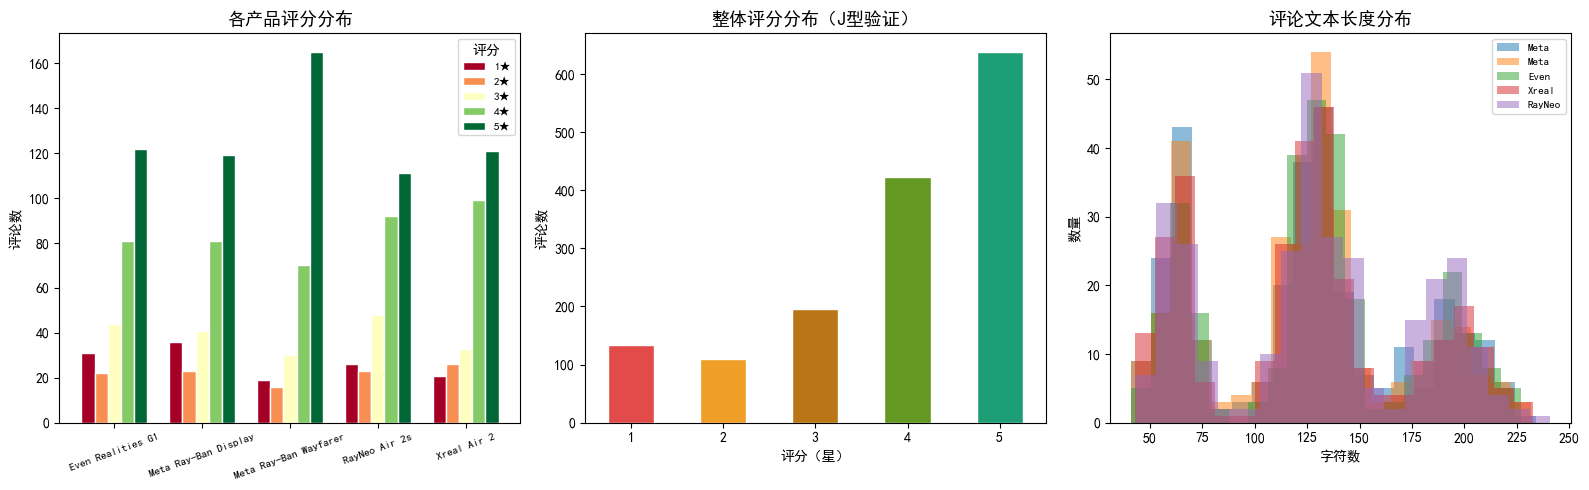

In [26]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 图1: 各产品评分分布
rating_ct = df.groupby(["product_name", "rating"]).size().unstack(fill_value=0)
rating_ct.plot(kind="bar", ax=axes[0], colormap="RdYlGn", edgecolor="white", width=0.75)
axes[0].set_title("各产品评分分布", fontsize=13, fontweight=500)
axes[0].set_xlabel("")
axes[0].set_ylabel("评论数")
axes[0].legend(title="评分", labels=["1★","2★","3★","4★","5★"], fontsize=8)
axes[0].tick_params(axis="x", rotation=20, labelsize=8)

# 图2: 整体评分分布
colors = ["#E24B4A","#EF9F27","#BA7517","#639922","#1D9E75"]
df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=colors, edgecolor="white"
)
axes[1].set_title("整体评分分布（J型验证）", fontsize=13, fontweight=500)
axes[1].set_xlabel("评分（星）")
axes[1].set_ylabel("评论数")
axes[1].tick_params(axis="x", rotation=0)

# 图3: 评论文本长度分布
df["text_length"] = df["review_text"].str.len()
for product in df["product_name"].unique():
    sub = df[df["product_name"] == product]
    axes[2].hist(sub["text_length"], bins=20, alpha=0.5, label=product.split(" ")[0])
axes[2].set_title("评论文本长度分布", fontsize=13, fontweight=500)
axes[2].set_xlabel("字符数")
axes[2].set_ylabel("数量")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/01_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3: 文本预处理与情感分析

文本预处理是NLP的基础工序：把原始评论文本清洗成机器可以处理的格式。
情感分析则是给每条评论打一个情感分数，量化"用户有多满意/不满意"。

处理流程：
1. 文本清洗（小写化、去标点、去停用词）
2. VADER情感打分（专为社交媒体/评论文本设计的规则型情感分析器）
3. 情感分数与评分的交叉验证

In [15]:
# 先安装并加载VADER情感分析器
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import re

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))

print("✅ NLP工具加载完毕")

✅ NLP工具加载完毕


In [16]:
# ============================================================
# 文本预处理函数
# ============================================================

def clean_text(text):
    """
    文本清洗三步:
    1. 小写化 - 统一大小写，避免 "Battery" 和 "battery" 被当成不同词
    2. 去标点 - 只保留字母和空格
    3. 去停用词 - 移除 "the", "is", "a" 等无实际含义的词
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

# 测试一下
sample_text = "The battery barely lasts 3 hours with heavy AI use. Not great."
print(f"原文: {sample_text}")
print(f"清洗: {clean_text(sample_text)}")

原文: The battery barely lasts 3 hours with heavy AI use. Not great.
清洗: battery barely lasts hours heavy use great


In [23]:
# 验证VADER对否定词的处理能力
test_cases = [
    "Not great.",
    "This is great.",
    "The battery barely lasts 3 hours with heavy AI use. Not great.",
    "Battery lasts all day for my normal use. Great product.",
]

for text in test_cases:
    score = sia.polarity_scores(text)["compound"]
    label = "positive" if score >= 0.05 else ("negative" if score <= -0.05 else "neutral")
    print(f"  [{label:>8}] {score:+.3f}  |  {text}")

  [negative] -0.510  |  Not great.
  [positive] +0.625  |  This is great.
  [negative] -0.510  |  The battery barely lasts 3 hours with heavy AI use. Not great.
  [positive] +0.625  |  Battery lasts all day for my normal use. Great product.


In [17]:
# ============================================================
# 对整个数据集做预处理 + 情感打分
# ============================================================

# 1. 文本清洗
df["clean_text"] = df["review_text"].apply(clean_text)

# 2. VADER情感分析
# VADER返回4个分数: neg(负面), neu(中性), pos(正面), compound(综合)
# compound 范围 [-1, 1]，-1极度负面，+1极度正面
df["sentiment_scores"] = df["review_text"].apply(lambda x: sia.polarity_scores(x))
df["sentiment_compound"] = df["sentiment_scores"].apply(lambda x: x["compound"])
df["sentiment_pos"] = df["sentiment_scores"].apply(lambda x: x["pos"])
df["sentiment_neg"] = df["sentiment_scores"].apply(lambda x: x["neg"])

# 3. 根据compound分数划分情感标签
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment_compound"].apply(label_sentiment)

# 删除临时列
df.drop(columns=["sentiment_scores"], inplace=True)

print(f"✅ 预处理完成，新增列: clean_text, sentiment_compound, sentiment_label")
print(f"\n--- 情感标签分布 ---")
print(df["sentiment_label"].value_counts().to_string())

✅ 预处理完成，新增列: clean_text, sentiment_compound, sentiment_label

--- 情感标签分布 ---
sentiment_label
positive    1084
negative     277
neutral      139


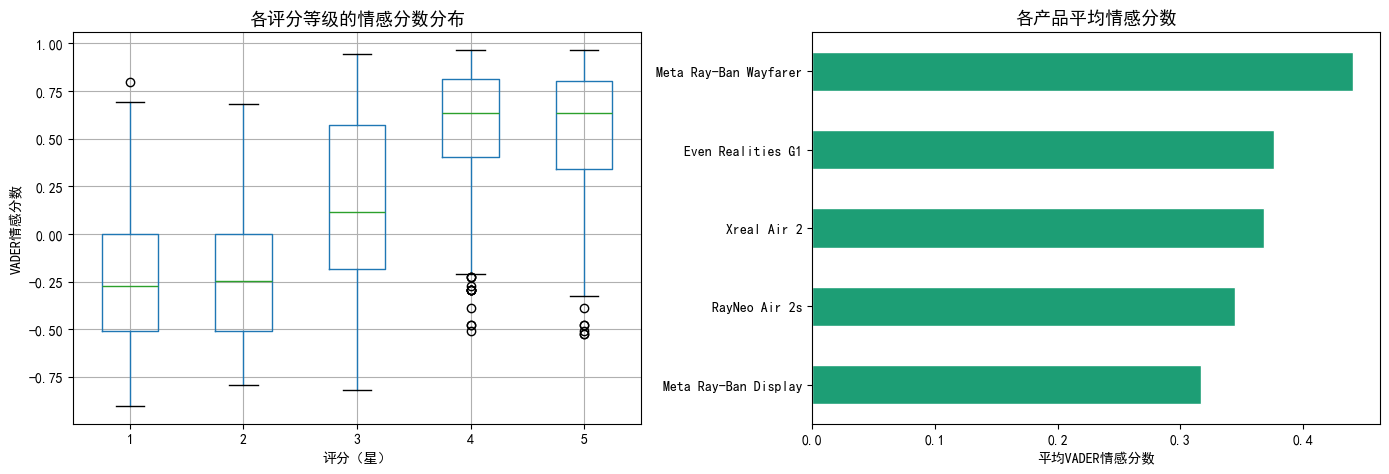

In [28]:
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1: 各评分等级的情感分数箱线图
df.boxplot(column="sentiment_compound", by="rating", ax=axes[0])
axes[0].set_title("各评分等级的情感分数分布", fontsize=13, fontweight=500)
axes[0].set_xlabel("评分（星）")
axes[0].set_ylabel("VADER情感分数")
axes[0].get_figure().suptitle("")

# 图2: 各产品的平均情感分数对比
product_sentiment = df.groupby("product_name")["sentiment_compound"].mean().sort_values()
product_sentiment.plot(kind="barh", ax=axes[1], color="#1D9E75", edgecolor="white")
axes[1].set_title("各产品平均情感分数", fontsize=13, fontweight=500)
axes[1].set_xlabel("平均VADER情感分数")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/02_sentiment_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4: 主题提取（Topic Extraction）

用两种方法提取评论中的话题：
1. **关键词匹配法** — 基于我们定义的taxonomy，用关键词规则匹配每条评论涉及的话题
2. **TF-IDF + 词频分析** — 无监督方法，看各产品评论中哪些词出现频率最高

两种方法互相验证：关键词法用产品认知驱动，TF-IDF用数据驱动，交叉对比更有说服力。

In [30]:
# ============================================================
# 方法1: 关键词匹配法
# 为每个topic定义一组关键词，扫描评论文本进行匹配
# ============================================================

TOPIC_KEYWORDS = {
    "佩戴舒适": ["comfort", "lightweight", "heavy", "nose", "ear", "weight", "pressure", "hurting", "sore", "sliding", "pinch"],
    "电池续航": ["battery", "charge", "charging", "hours", "drain", "dies", "case charge", "fast charging"],
    "音频质量": ["audio", "speaker", "sound", "bass", "music", "podcast", "microphone", "call quality", "volume", "leaks"],
    "相机质量": ["camera", "photo", "video", "12mp", "recording", "stabilization", "image", "footage", "capture"],
    "处方镜片": ["prescription", "lens", "optician", "progressive"],
    "做工耐用": ["build", "hinge", "durable", "scratch", "flimsy", "plastic", "corroded", "premium"],
    "充电方式": ["charging case", "usb-c", "usb", "magnetic", "pogo", "proprietary"],
    "发热问题": ["heat", "warm", "hot", "thermal", "temperature"],
    "外观设计": ["look", "style", "fashion", "design", "bulky", "cyborg", "dorky", "sleek", "compliment"],
    "显示效果": ["display", "screen", "oled", "fov", "field of view", "brightness", "resolution", "refresh", "virtual screen", "130-inch"],
    "AI语音": ["ai", "meta ai", "voice command", "voice recognition", "wake word", "hey meta", "translation", "identify"],
    "App体验": ["app", "companion app", "software", "ui", "crash", "clunky", "intuitive"],
    "视觉疲劳": ["eye strain", "headache", "eye hurt", "nausea", "focus distance", "splitting headache"],
    "设备兼容": ["compatibility", "compatible", "iphone", "android", "nebula", "beam", "adapter", "usb-c", "steam deck", "windows"],
    "地区限制": ["geo-block", "region", "country", "vpn", "not available"],
    "软件更新": ["update", "bug", "fix", "patch", "abandoned", "promised"],
    "导航翻译": ["navigation", "gps", "direction", "translation", "translate", "teleprompter", "hud"],
    "蓝牙稳定": ["bluetooth", "disconnect", "connection", "pair", "dropout", "stutter"],
    "用户隐私": ["privacy", "data", "recording", "meta stores", "cloud", "train ai", "voice recording"],
    "旁观者隐私": ["uncomfortable", "creepy", "recording me", "led light", "cafe", "banned", "stigma", "trust issue"],
    "性价比": ["price", "worth", "expensive", "overpriced", "value", "money", "dollar"],
    "配件成本": ["accessory", "beam", "adapter", "extra cost", "clip-on", "shades", "additional"],
    "第三方应用": ["spotify", "uber", "google maps", "smart home", "whatsapp", "instagram", "third-party", "ecosystem"],
    "社会接受度": ["social", "public", "stare", "awkward", "accepted", "gym", "restaurant", "coworker"],
}

def extract_topics(text):
    """扫描评论文本，返回匹配到的所有话题"""
    text_lower = text.lower()
    matched = []
    for topic, keywords in TOPIC_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                matched.append(topic)
                break  # 一个topic匹配到一个关键词就够了
    return matched

# 对整个数据集提取话题
df["extracted_topics"] = df["review_text"].apply(extract_topics)
df["n_topics"] = df["extracted_topics"].apply(len)

print("✅ 关键词话题提取完成")
print(f"平均每条评论匹配到 {df['n_topics'].mean():.1f} 个话题")
print(f"匹配到0个话题的评论: {(df['n_topics']==0).sum()} 条")

✅ 关键词话题提取完成
平均每条评论匹配到 2.9 个话题
匹配到0个话题的评论: 34 条


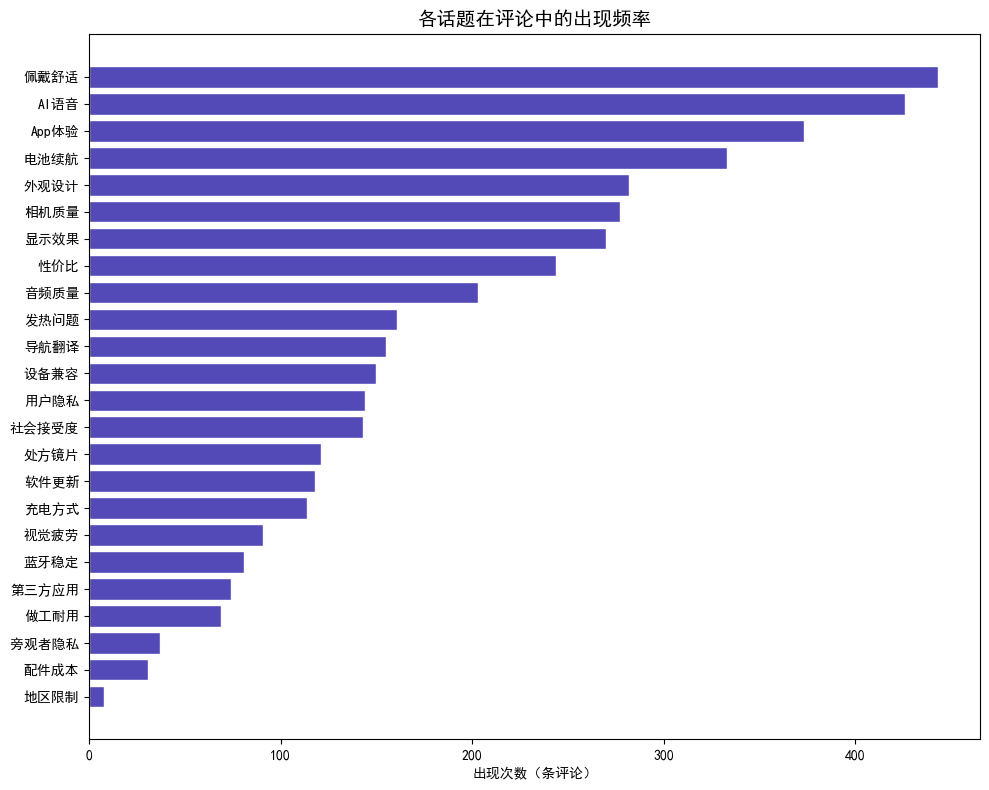

In [31]:
# ============================================================
# 各话题在所有评论中的出现频率
# ============================================================

from collections import Counter

all_topics_flat = [t for topics in df["extracted_topics"] for t in topics]
topic_counts = Counter(all_topics_flat)
topic_df = pd.DataFrame(topic_counts.items(), columns=["话题", "出现次数"]).sort_values("出现次数", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(topic_df["话题"], topic_df["出现次数"], color="#534AB7", edgecolor="white")
ax.set_title("各话题在评论中的出现频率", fontsize=14, fontweight=500)
ax.set_xlabel("出现次数（条评论）")

plt.tight_layout()
plt.savefig("../outputs/03_topic_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5: 竞品痛点地图（核心产出）

将话题提取和情感分析的结果交叉，生成 产品×话题 的情感热力图。
每个格子的值 = 该产品在该话题下所有评论的平均情感分数。
红色 = 痛点（用户不满），绿色 = 亮点（用户满意）。

In [33]:
# ============================================================
# 构建 产品×话题 的情感矩阵
# ============================================================

# 先把extracted_topics展开：每条评论的每个话题单独一行
rows = []
for _, row in df.iterrows():
    for topic in row["extracted_topics"]:
        rows.append({
            "product_name": row["product_name"],
            "topic": topic,
            "sentiment": row["sentiment_compound"],
            "rating": row["rating"],
        })

topic_detail = pd.DataFrame(rows)

# 计算 产品×话题 的平均情感分数
pivot_sentiment = topic_detail.pivot_table(
    index="topic", columns="product_name",
    values="sentiment", aggfunc="mean"
)

# 计算 产品×话题 的评论数量（用于过滤样本太少的格子）
pivot_count = topic_detail.pivot_table(
    index="topic", columns="product_name",
    values="sentiment", aggfunc="count"
)

# 过滤：某产品某话题评论少于5条的，情感分数不可靠，设为NaN
pivot_sentiment[pivot_count < 5] = np.nan

print(f"✅ 情感矩阵构建完成: {pivot_sentiment.shape[0]} 个话题 × {pivot_sentiment.shape[1]} 个产品")
print(f"有效格子: {pivot_sentiment.notna().sum().sum()} / {pivot_sentiment.size}")

✅ 情感矩阵构建完成: 24 个话题 × 5 个产品
有效格子: 107 / 120


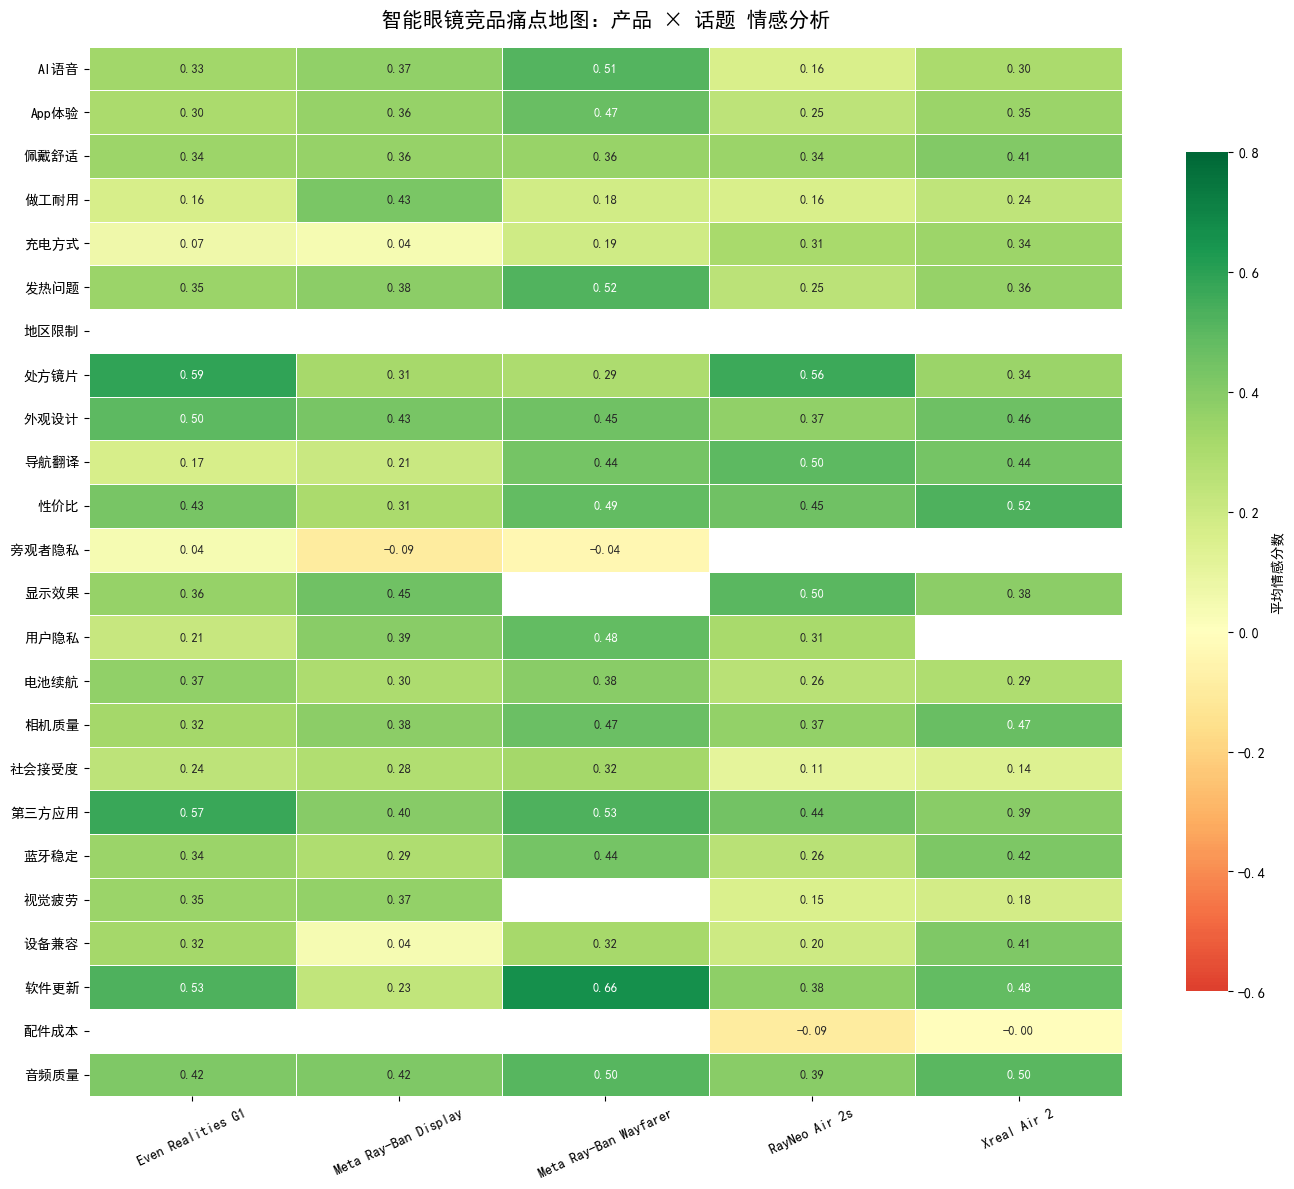

In [34]:
# ============================================================
# 竞品痛点热力图
# ============================================================

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    pivot_sentiment,
    annot=True, fmt=".2f",
    cmap="RdYlGn",       # 红=负面, 黄=中性, 绿=正面
    center=0,
    vmin=-0.6, vmax=0.8,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "平均情感分数", "shrink": 0.8},
    ax=ax,
    annot_kws={"size": 9},
)

ax.set_title("智能眼镜竞品痛点地图：产品 × 话题 情感分析", fontsize=15, fontweight=500, pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=25, labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()
plt.savefig("../outputs/04_pain_point_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 6: 痛点深挖 — 只看负面评论

整体情感均值被大量正面评论稀释了，痛点不够突出。
换一个视角：只筛选1-2星评论，看各产品的用户到底在抱怨什么。

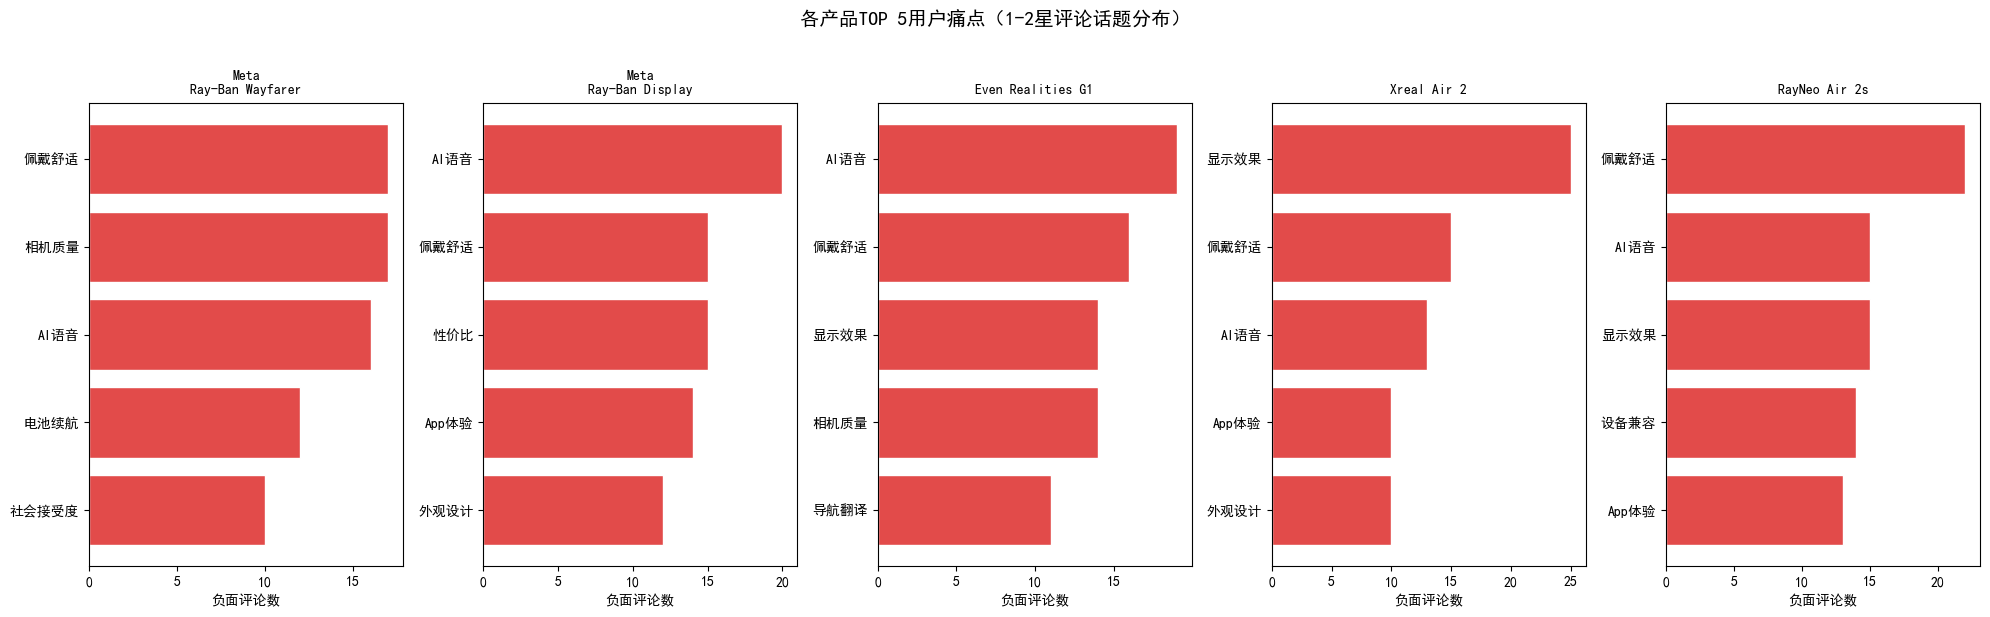

In [35]:
# ============================================================
# 只看1-2星评论：各产品的痛点话题TOP 5
# ============================================================

negative_df = df[df["rating"] <= 2].copy()

# 展开话题
neg_rows = []
for _, row in negative_df.iterrows():
    for topic in row["extracted_topics"]:
        neg_rows.append({
            "product_name": row["product_name"],
            "topic": topic,
        })

neg_topic_df = pd.DataFrame(neg_rows)

# 计算各产品各话题的负面评论数
neg_pivot = neg_topic_df.groupby(["product_name", "topic"]).size().reset_index(name="neg_count")

# 画图：每个产品的负面话题TOP5
products = df["product_name"].unique()
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=False)

for idx, product in enumerate(products):
    sub = neg_pivot[neg_pivot["product_name"] == product].nlargest(5, "neg_count")
    axes[idx].barh(sub["topic"], sub["neg_count"], color="#E24B4A", edgecolor="white")
    axes[idx].set_title(product.replace("Meta ", "Meta\n"), fontsize=10, fontweight=500)
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel("负面评论数")
    if idx > 0:
        axes[idx].set_ylabel("")

fig.suptitle("各产品TOP 5用户痛点（1-2星评论话题分布）", fontsize=14, fontweight=500, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/05_pain_points_by_product.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: 保存完整分析结果

In [39]:
# 保存带有情感分数和话题标签的完整数据集
output_cols = [
    "product_name", "brand", "category", "price", "rating",
    "review_title", "review_text", "clean_text", "review_date",
    "verified_purchase", "sentiment_compound", "sentiment_pos",
    "sentiment_neg", "sentiment_label", "extracted_topics", "n_topics"
]

# extracted_topics是list，需要转成字符串保存
df["extracted_topics_str"] = df["extracted_topics"].apply(lambda x: "|".join(x))
df_save = df[output_cols].copy()
df_save["extracted_topics"] = df["extracted_topics_str"]

df_save.to_csv("../data/smart_glasses_reviews_analyzed.csv", index=False)
print(f"✅ 完整分析结果已保存: data/smart_glasses_reviews_analyzed.csv")
print(f"   共 {len(df_save)} 条评论, {len(output_cols)} 个字段")

✅ 完整分析结果已保存: data/smart_glasses_reviews_analyzed.csv
   共 1500 条评论, 16 个字段


## Step 7: TF-IDF词频分析

用无监督方法看各产品负面评论中的高频关键词，和关键词匹配法做交叉验证。
TF-IDF（词频-逆文档频率）会自动找出"在某产品评论中频繁出现，但在其他产品中不常见"的特征词。

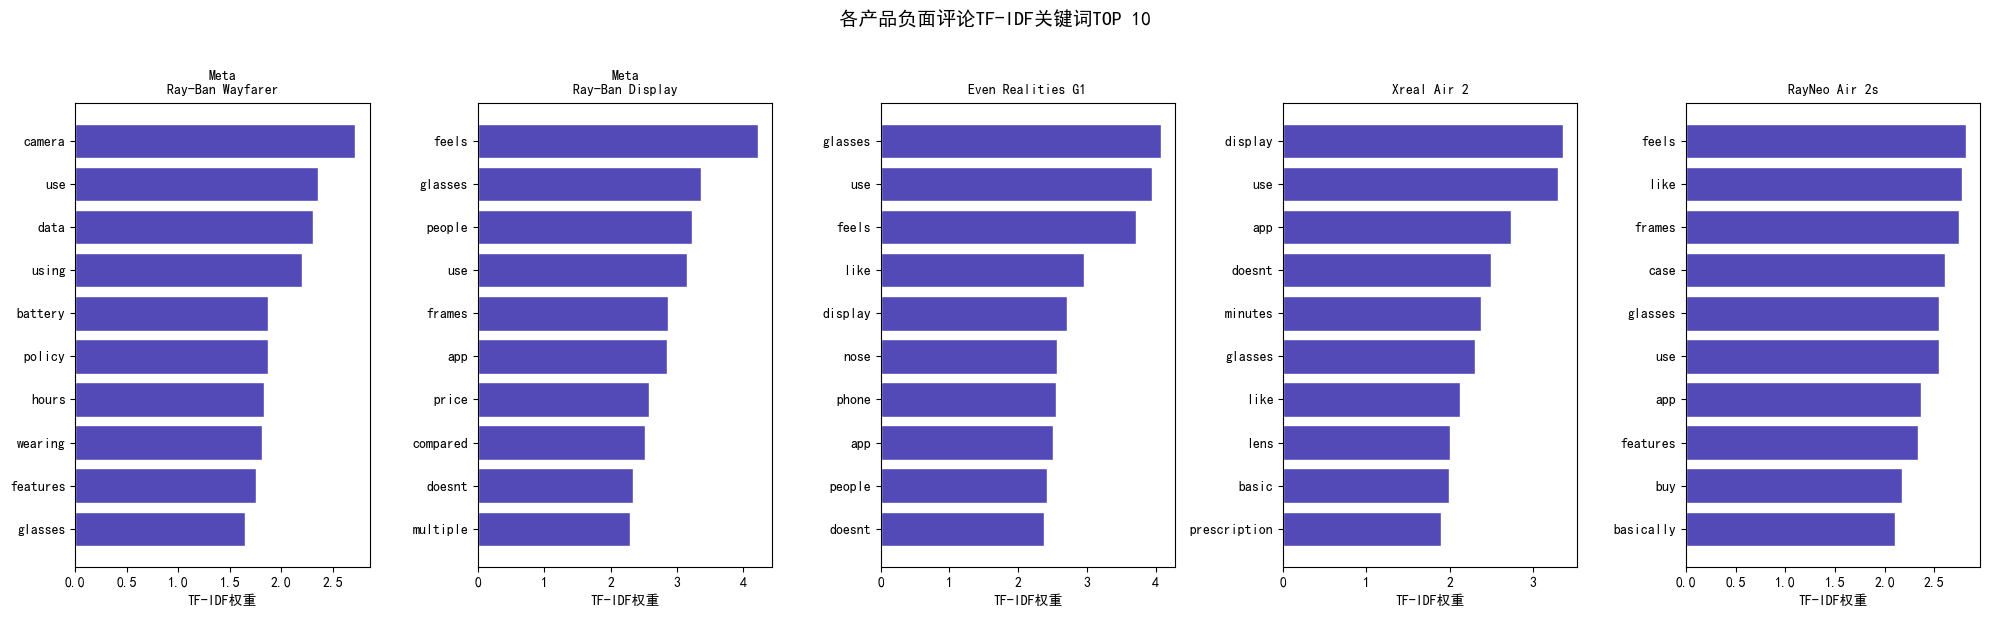

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 只看负面评论
negative_df = df[df["rating"] <= 2].copy()

fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=False)

for idx, product in enumerate(products):
    sub = negative_df[negative_df["product_name"] == product]
    
    if len(sub) < 5:
        axes[idx].set_title(product, fontsize=10)
        axes[idx].text(0.5, 0.5, "样本不足", ha="center", va="center")
        continue
    
    # TF-IDF提取该产品负面评论的关键词
    tfidf = TfidfVectorizer(max_features=100, stop_words="english", ngram_range=(1,2))
    matrix = tfidf.fit_transform(sub["clean_text"])
    
    # 按TF-IDF权重排序取TOP10
    feature_names = tfidf.get_feature_names_out()
    scores = matrix.sum(axis=0).A1
    top_idx = scores.argsort()[-10:][::-1]
    
    top_words = [feature_names[i] for i in top_idx]
    top_scores = [scores[i] for i in top_idx]
    
    axes[idx].barh(top_words[::-1], top_scores[::-1], color="#534AB7", edgecolor="white")
    axes[idx].set_title(product.replace("Meta ", "Meta\n"), fontsize=10, fontweight=500)
    axes[idx].set_xlabel("TF-IDF权重")
    if idx > 0:
        axes[idx].set_ylabel("")

fig.suptitle("各产品负面评论TF-IDF关键词TOP 10", fontsize=14, fontweight=500, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/06_tfidf_negative.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9: 分析结论

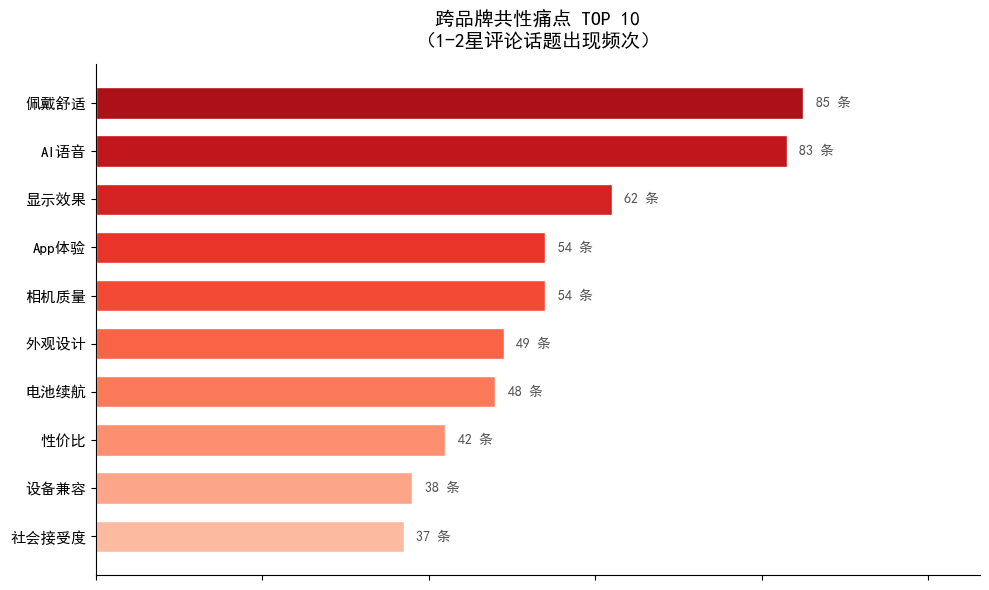

In [38]:
# ============================================================
# 9.1 跨品牌共性痛点：所有产品中负面评论最集中的话题
# ============================================================

# 统计每个话题在1-2星评论中的出现次数
neg_rows_all = []
for _, row in df[df["rating"] <= 2].iterrows():
    for topic in row["extracted_topics"]:
        neg_rows_all.append({"topic": topic})

neg_all = pd.DataFrame(neg_rows_all)
common_pain = neg_all["topic"].value_counts().head(10).sort_values()

# 渐变红色：越严重越深
colors = plt.cm.Reds(np.linspace(0.25, 0.85, len(common_pain)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(common_pain.index, common_pain.values, color=colors, edgecolor="white", height=0.65)

# 在柱子末端标注数值
for bar, val in zip(bars, common_pain.values):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f"{val} 条", va="center", fontsize=10, color="#555")

ax.set_title("跨品牌共性痛点 TOP 10\n（1-2星评论话题出现频次）", fontsize=14, fontweight=500, pad=12)
ax.set_xlabel("")
ax.set_xlim(0, common_pain.max() * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelbottom=False)

plt.tight_layout()
plt.savefig("../outputs/07_common_pain_points.png", dpi=150, bbox_inches="tight")
plt.show()

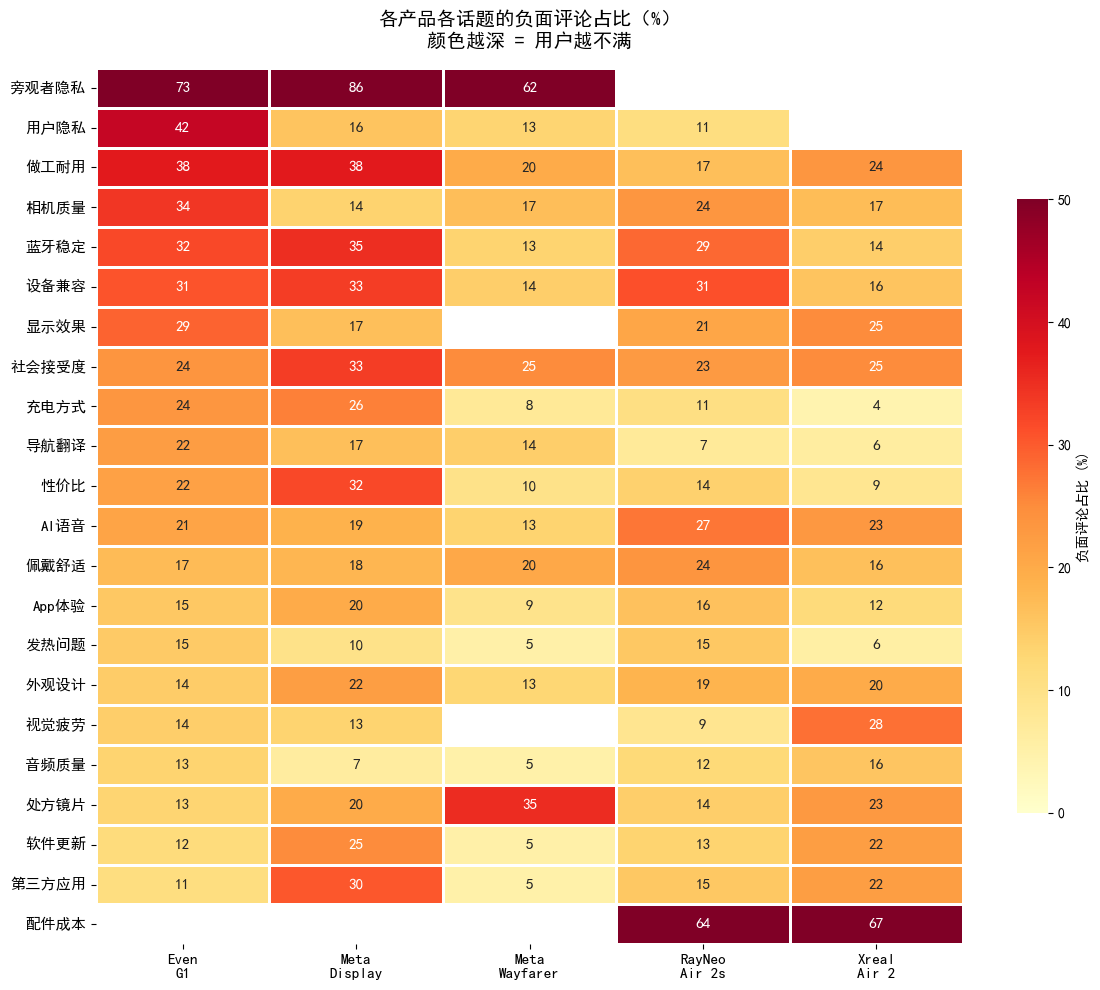

In [40]:
# ============================================================
# 9.2 各产品独特痛点：负面评论中话题占比对比（分组热力图）
# ============================================================

# 计算每个产品每个话题的负面评论占比
pain_rows = []
for _, row in df.iterrows():
    for topic in row["extracted_topics"]:
        pain_rows.append({
            "product_name": row["product_name"],
            "topic": topic,
            "is_negative": 1 if row["rating"] <= 2 else 0,
        })

pain_df = pd.DataFrame(pain_rows)
pain_ratio = pain_df.groupby(["product_name", "topic"]).agg(
    neg_ratio=("is_negative", "mean"),
    total=("is_negative", "count")
).reset_index()

# 过滤样本太少的组合
pain_ratio = pain_ratio[pain_ratio["total"] >= 5]

# 透视成矩阵
pain_matrix = pain_ratio.pivot_table(index="topic", columns="product_name", values="neg_ratio")

# 只保留至少有一个产品负面占比>15%的话题（去掉不痛不痒的）
pain_matrix = pain_matrix[pain_matrix.max(axis=1) > 0.15].sort_values(
    by=list(pain_matrix.columns), ascending=False
)

# 短名映射
short_names = {
    "Meta Ray-Ban Wayfarer": "Meta\nWayfarer",
    "Meta Ray-Ban Display": "Meta\nDisplay",
    "Even Realities G1": "Even\nG1",
    "Xreal Air 2": "Xreal\nAir 2",
    "RayNeo Air 2s": "RayNeo\nAir 2s",
}
pain_matrix_plot = pain_matrix.rename(columns=short_names)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    pain_matrix_plot * 100,  # 转成百分比
    annot=True, fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.8, linecolor="white",
    cbar_kws={"label": "负面评论占比 (%)", "shrink": 0.7},
    ax=ax,
    annot_kws={"size": 11, "fontweight": 500},
    vmin=0, vmax=50,
)

ax.set_title("各产品各话题的负面评论占比（%）\n颜色越深 = 用户越不满", fontsize=14, fontweight=500, pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=11, rotation=0)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()
plt.savefig("../outputs/08_pain_ratio_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

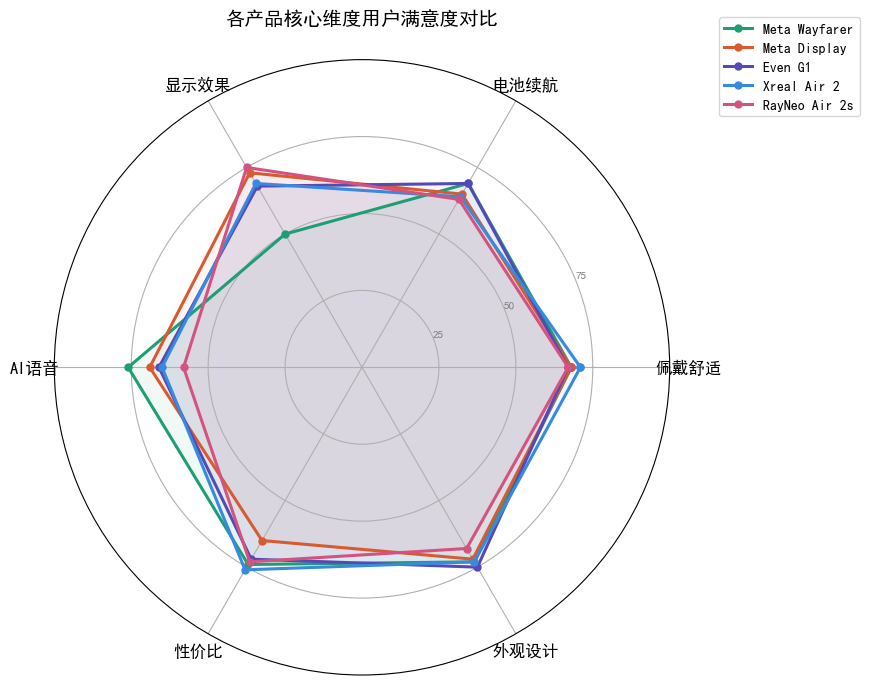

In [41]:
# ============================================================
# 9.3 竞争力雷达图：6个核心维度的用户满意度对比
# ============================================================

key_dims = ["佩戴舒适", "电池续航", "显示效果", "AI语音", "性价比", "外观设计"]

# 用情感均值作为得分，映射到0-100
radar_data = {}
for product in products:
    scores = []
    for dim in key_dims:
        if dim in pivot_sentiment.index and product in pivot_sentiment.columns:
            val = pivot_sentiment.loc[dim, product]
        else:
            val = 0
        if pd.isna(val):
            val = 0
        scores.append(round((val + 1) * 50))  # [-1,1] → [0,100]
    radar_data[product] = scores

# 雷达图
angles = np.linspace(0, 2 * np.pi, len(key_dims), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors = ["#1D9E75", "#D85A30", "#534AB7", "#378ADD", "#D4537E"]
short_labels = {
    "Meta Ray-Ban Wayfarer": "Meta Wayfarer",
    "Meta Ray-Ban Display": "Meta Display",
    "Even Realities G1": "Even G1",
    "Xreal Air 2": "Xreal Air 2",
    "RayNeo Air 2s": "RayNeo Air 2s",
}

for idx, (product, scores) in enumerate(radar_data.items()):
    values = scores + scores[:1]
    ax.plot(angles, values, "o-", linewidth=2.2, label=short_labels[product],
            color=colors[idx], markersize=5)
    ax.fill(angles, values, alpha=0.06, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(key_dims, fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75])
ax.set_yticklabels(["25", "50", "75"], fontsize=8, color="gray")
ax.set_title("各产品核心维度用户满意度对比", fontsize=14, fontweight=500, pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.32, 1.08), fontsize=10,
          frameon=True, fancybox=True, shadow=False)

plt.tight_layout()
plt.savefig("../outputs/09_radar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 分析结论

### 1. 跨品牌共性痛点
- **佩戴舒适度**（85条负面）和**AI语音**（83条负面）是所有智能眼镜产品的TOP 2用户抱怨
- 说明整个品类在"长时间佩戴体验"和"AI交互可靠性"上都还没过及格线
- **App体验**和**显示效果**紧随其后，软件完成度普遍跟不上硬件

### 2. 各产品差异化痛点
| 产品 | 核心痛点 | 负面占比 |
|------|---------|---------|
| Meta Wayfarer | 旁观者隐私、处方镜片适配 | 62%、35% |
| Meta Display | 旁观者隐私、做工耐用、蓝牙稳定、性价比 | 86%、38%、35%、32% |
| Even G1 | 旁观者隐私、用户隐私、做工耐用、相机质量 | 73%、42%、38%、34% |
| Xreal Air 2 | 配件成本、视觉疲劳、显示效果、社会接受度 | 67%、28%、25%、25% |
| RayNeo Air 2s | 配件成本、设备兼容、蓝牙稳定、AI语音 | 64%、31%、29%、27% |

### 3. 对产品设计的启示
- 做新一代智能眼镜，**佩戴舒适度**必须是优先级最高的体验指标
- 带相机的产品需要正面解决**旁观者隐私**问题，否则社会接受度会成为增长瓶颈
- 屏幕类眼镜（Xreal/RayNeo）的**配件成本**是隐藏的劝退因素，基础功能不应依赖额外购买
- **App和软件生态**是被低估的竞争维度，硬件厂商普遍在这里丢分
- Meta的隐私争议是竞品的差异化机会——如果能在隐私保护上做出明确承诺，可以争取Meta的不满用户